In [4]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
import rioxarray
from scipy.stats import gaussian_kde

In [5]:
def read_valid_pixels_sdat(sdat_path):
    # open .sdat
    da = rioxarray.open_rasterio(sdat_path)

    data = da.values[0].astype(float)

    # replace nodata with NaN
    if da.rio.nodata is not None:
        data[data == da.rio.nodata] = np.nan

    return data[~np.isnan(data)]

In [6]:
slope_files = {
    "2012": "2012_slope.sdat",
    "2013": "2013_slope.sdat",
    #"2014": "2014_slope.sdat",
    "2015": "2015_slope.sdat",
}

slope_data = {label: read_valid_pixels_sdat(path)
             for label, path in slope_files.items()}

In [12]:
colors = {
    "2012": "#2171b5",  # blue
    "2013": "#31a354",  # green
    "2015": "#8c6d31",  # brown
}

plt.rcParams.update({
    "font.family": "Arial", 
    "font.size": 18, 
    "axes.labelsize": 18, 
    "axes.titlesize": 18,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
    "axes.linewidth": 1.0,
    "xtick.major.width": 1.0,
    "ytick.major.width": 1.0,
})

# Shared x-range
all_values = np.concatenate(list(slope_data.values()))
x = np.linspace(np.min(all_values), np.max(all_values), 600)

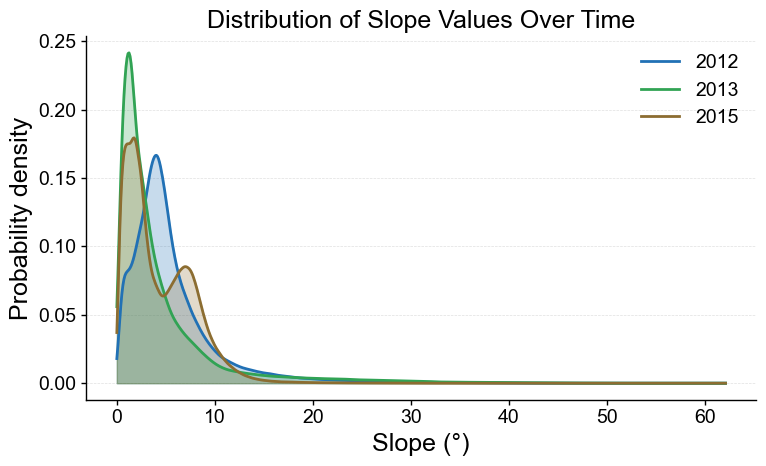

In [13]:
fig, ax = plt.subplots(figsize=(8, 5))

for label, data in slope_data.items():
    kde = gaussian_kde(data)
    y = kde(x)
    color = colors[label]

    # shaded KDE
    ax.fill_between(
        x, y,
        color=color,
        alpha=0.25
    )

    # outline of KDE
    ax.plot(
        x, y,
        color=color,
        linewidth=2, 
        alpha=1.0, 
        label=label
    )

ax.set_xlabel("Slope (\u00B0)")
ax.set_ylabel("Probability density")
ax.set_title("Distribution of Slope Values Over Time")

ax.legend(frameon=False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.yaxis.grid(True, linestyle="--", linewidth=0.5, alpha=0.4)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()